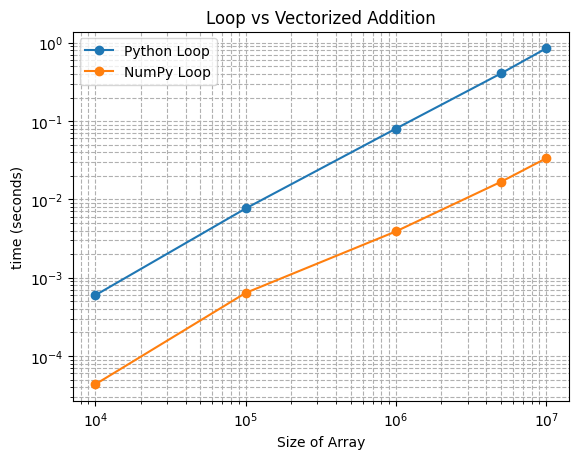

size     10000: python 0.0006s, numpy 0.0000s, speedup 13.7x
size    100000: python 0.0076s, numpy 0.0006s, speedup 12.0x
size   1000000: python 0.0801s, numpy 0.0039s, speedup 20.6x
size   5000000: python 0.4060s, numpy 0.0168s, speedup 24.2x
size  10000000: python 0.8498s, numpy 0.0335s, speedup 25.4x


In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt

def python_add(n):
    a = list(range(n))
    b = list(range(n))
    start = time.time()
    c = [a[i] + b[i] for i in range(n)]
    return time.time() - start

def numpy_add(n):
    a = np.arange(n)
    b = np.arange(n)
    start = time.time()
    c = a + b
    return time.time() - start

sizes = [10_000, 100_000, 1_000_000, 5_000_000, 10_000_000]
py_times = []
np_times = []

for s in sizes:
    py_times.append(python_add(s))
    np_times.append(numpy_add(s))

#Difference Plot

plt.loglog(sizes, py_times, marker='o', label='Python Loop')
plt.loglog(sizes, np_times, marker='o', label='NumPy Loop')
plt.xlabel('Size of Array')
plt.ylabel('time (seconds)')
plt.title('Loop vs Vectorized Addition')
plt.grid(True, which='both', ls='--')
plt.legend()
plt.show()


for s, pt, nt in zip(sizes, py_times, np_times):
    if nt == 0:
        speedup = float('inf')
    else:
        speedup = pt / nt
    print(f'size {s:>9}: python {pt:.4f}s, numpy {nt:.4f}s, speedup {speedup:.1f}x')
